# 07 · Correlation assumptions & hypothesis testing

Notebook 01 measured raw Pearson correlation. That's where beginners *stop* and pros get *suspicious*. Here we:
1. Stress-test the **assumptions** behind correlation (linearity) and bring in **Spearman** + **mutual information**.
2. Ask whether a correlation is **real or luck** (significance, p-values, effect size, the big-N trap).
3. **Formulate a proper hypothesis** (H0/H1) and **test it** with a t-test — *and* confirm it survives **out-of-sample**.

This is the bridge from 'looking at data' to 'making a defensible claim about it'.

> ⏱️ **~30 min** &nbsp;·&nbsp; 🧭 **SOP:** Phase 6 · hypothesis &nbsp;·&nbsp; 🧩 **Feeds:** discovery (08) and the strategy hypotheses (MasterVP / Monster / KenKem)
>
> 🎯 **Goal:** Tell a real, robust relationship from a lucky one — Pearson vs Spearman vs MI, p-values, effect size, out-of-sample.
>
> 🔑 **The one thing to remember:** Significance ≠ importance. With 400k rows *everything* is 'significant' — demand effect size + out-of-sample replication.

🔗 **Where this sits in the journey.** You are now *downstream* of notebooks **00–04**: the `features_*.parquet` and `labels_*.parquet` you load here were imported (00), cleaned (01), barred (02), engineered (03) and labeled (04) in those notebooks. If a column here is a mystery, that's where it was born. Keep `GLOSSARY.md` open in a tab.

## Block 0 · Setup + load

In [1]:
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
try:
    import seaborn as sns; sns.set_theme(style='whitegrid'); HAVE_SNS=True
except ImportError: HAVE_SNS=False

ROOT = Path.cwd()
while not (ROOT/'CLAUDE.md').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
DATA = ROOT/'data'
df = duckdb.sql(f"""
    SELECT f.*, l.fwd_ret_5, l.fwd_ret_10, l.fwd_ret_20, l.fwd_ret_60
    FROM '{DATA}/features/features_btcusd_M3.parquet' f
    JOIN '{DATA}/labels/labels_btcusd_M3.parquet' l USING (ts)
    ORDER BY f.ts
""").df()
label_cols = ['fwd_ret_5','fwd_ret_10','fwd_ret_20','fwd_ret_60']
feat_cols = [c for c in df.select_dtypes('number').columns if c not in label_cols]
print(f'{len(df):,} rows | {len(feat_cols)} features')

424,729 rows | 41 features


## Block 1 · The assumption Pearson hides: linearity
**Pearson** correlation only measures *straight-line* association. A strong but *curved* relationship can read near-zero. Two better tools:
- **Spearman** — correlation of *ranks*; catches any **monotonic** (always-up or always-down, even if curved) relationship.
- **Mutual information (MI)** — measures *any* dependency including non-monotonic; 0 only if truly independent. Can't be negative, no direction.

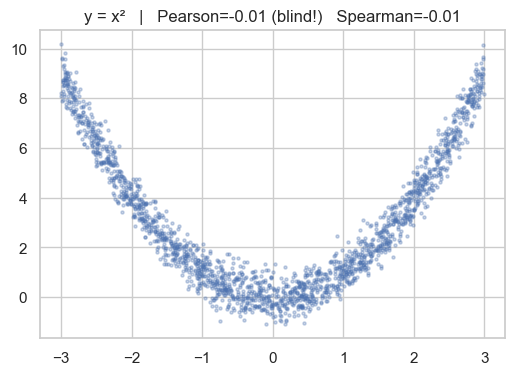

Lesson: Pearson ~0 does NOT mean "no relationship". Always plot; cross-check with Spearman/MI.


In [2]:
# Demonstration: a perfectly dependent but non-linear pair where Pearson lies.
rng = np.random.default_rng(0)
x = rng.uniform(-3, 3, 2000)
y = x**2 + rng.normal(0, 0.5, 2000)        # y depends ENTIRELY on x, but via a U-shape
pear = stats.pearsonr(x, y)[0]
spear = stats.spearmanr(x, y)[0]
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x, y, s=5, alpha=0.3)
ax.set_title(f'y = x²   |   Pearson={pear:.2f} (blind!)   Spearman={spear:.2f}')
plt.show()
print('Lesson: Pearson ~0 does NOT mean "no relationship". Always plot; cross-check with Spearman/MI.')

In [3]:
# Now on REAL data: rank features 3 ways against fwd_ret_10 and compare.
from sklearn.feature_selection import mutual_info_regression

target = 'fwd_ret_10'
d = df[feat_cols + [target]].dropna()
# subsample for MI speed (MI is O(n log n) per feature with kNN estimator)
ds = d.sample(min(40000, len(d)), random_state=0)
X, ytgt = ds[feat_cols], ds[target]

pearson  = X.corrwith(ytgt)
spearman = X.corrwith(ytgt, method='spearman')
mi = pd.Series(mutual_info_regression(X, ytgt, random_state=0), index=feat_cols)

cmp = pd.DataFrame({'pearson': pearson, 'spearman': spearman, 'mutual_info': mi})
cmp['abs_pearson'] = cmp.pearson.abs()
print('Top 12 features by mutual information (catches non-linear signal Pearson may miss):\n')
print(cmp.sort_values('mutual_info', ascending=False).head(12).round(4).to_string())

Top 12 features by mutual information (catches non-linear signal Pearson may miss):

                 pearson  spearman  mutual_info  abs_pearson
atr               0.0226    0.0135       0.1053       0.0226
ema_compression   0.0261    0.0060       0.0596       0.0261
ema_100_dist     -0.0151   -0.0344       0.0542       0.0151
ema_100_slope    -0.0134   -0.0321       0.0520       0.0134
ema_75_dist      -0.0161   -0.0363       0.0518       0.0161
ema_50_dist      -0.0175   -0.0371       0.0510       0.0175
ema_200_slope    -0.0130   -0.0287       0.0502       0.0130
ema_75_slope     -0.0145   -0.0338       0.0490       0.0145
dist_kijun       -0.0091   -0.0321       0.0486       0.0091
ema_25_dist      -0.0176   -0.0349       0.0484       0.0176
ema_50_slope     -0.0161   -0.0356       0.0478       0.0161
ema_200_dist     -0.0148   -0.0302       0.0478       0.0148


## Block 2 · Is a correlation real, or luck? (significance & the big-N trap)
A correlation number alone is meaningless without knowing how likely it'd appear *by chance*. `scipy.stats.pearsonr` returns the **p-value**: the probability of seeing a correlation this large if the true correlation were zero.

⚠️ **The big-N trap (read twice):** with hundreds of thousands of rows, *even microscopic correlations become 'statistically significant'* (p < 0.05). Significance answers 'is it non-zero?', **not** 'is it big enough to trade?'. For that you need **effect size** and out-of-sample stability.

In [4]:
feat = 'di_spread'
sub = df[[feat, target]].dropna()
r, p = stats.pearsonr(sub[feat], sub[target])
print(f'{feat} vs {target}:  r = {r:.4f}   p = {p:.2e}   n = {len(sub):,}')
print(f'  -> {"significant" if p<0.05 else "not significant"} (p<0.05), but r is tiny: explains {100*r**2:.2f}% of variance')

# Bootstrap a confidence interval for r — how stable is it across resamples of the data?
vals = sub.to_numpy(); n=len(vals); rng=np.random.default_rng(1)
boot = [stats.pearsonr(*vals[rng.integers(0,n,n)].T)[0] for _ in range(300)]
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f'  bootstrap 95% CI for r: [{lo:.4f}, {hi:.4f}]')
print('  Takeaway: "significant" + "tiny effect" is the normal state of a single feature in markets.')

di_spread vs fwd_ret_10:  r = 0.0035   p = 2.16e-02   n = 424,719
  -> significant (p<0.05), but r is tiny: explains 0.00% of variance


  bootstrap 95% CI for r: [-0.0002, 0.0072]
  Takeaway: "significant" + "tiny effect" is the normal state of a single feature in markets.


## Block 3 · Formulate a hypothesis (the structured way)
A tradeable claim must be written so it can be *proven wrong*. The template:

> **Idea:** trend-continuation — when the DMI says we're in a directional uptrend, the next move tends up.
>
> **Signal rule:** `adx > 25` (trend is strong) **and** `di_plus > di_minus` (trend is up).
>
> **H0 (null):** mean `fwd_ret_10` for signal bars = 0 (the signal is worthless).
> **H1 (alt.):** mean `fwd_ret_10` for signal bars > 0.
>
> **Decision rule:** reject H0 only if p < 0.05 **and** the effect survives out-of-sample.

We write the null as 'no edge' on purpose — we make the data work to overturn our skepticism.

In [5]:
# Build the signal. Crucial: split by TIME first, so the test set is genuinely the future.
d = df.dropna(subset=['adx','di_plus','di_minus','fwd_ret_10']).reset_index(drop=True)
split = int(len(d) * 0.7)
train, test = d.iloc[:split], d.iloc[split:]          # 70% past = in-sample, 30% future = out-of-sample
print(f'train: {train.ts.min()} -> {train.ts.max()}  ({len(train):,})')
print(f'test : {test.ts.min()} -> {test.ts.max()}  ({len(test):,})')

def signal(x): return (x['adx'] > 25) & (x['di_plus'] > x['di_minus'])
for name, part in [('train', train), ('test', test)]:
    s = signal(part)
    print(f'{name}: signal fires on {s.mean()*100:.1f}% of bars ({s.sum():,} bars)')

train: 2024-01-01 00:00:00 -> 2025-09-17 05:51:00  (297,303)
test : 2025-09-17 05:54:00 -> 2026-06-09 23:27:00  (127,416)
train: signal fires on 19.4% of bars (57,761 bars)
test: signal fires on 21.5% of bars (27,350 bars)


## Block 4 · Run the hypothesis test
Three pieces: a **t-test** (is the mean return > 0?), an **effect size** (Cohen's d — is it *big*?), and the **out-of-sample replication** (does it hold on data we didn't look at?).

In [6]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na-1)*a.var() + (nb-1)*b.var()) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled

def test_signal(part, label):
    s = signal(part)
    sig, nonsig = part.loc[s, 'fwd_ret_10'], part.loc[~s, 'fwd_ret_10']
    # one-sample: is signal-group mean return > 0?
    t1, p1 = stats.ttest_1samp(sig, 0)
    p1_one = p1/2 if t1 > 0 else 1 - p1/2          # one-sided (we predicted > 0)
    # two-sample: do signal bars beat non-signal bars?
    t2, p2 = stats.ttest_ind(sig, nonsig, equal_var=False)
    d = cohens_d(sig, nonsig)
    print(f'--- {label} ---')
    print(f'  signal mean fwd_ret_10 = {sig.mean()*1e4:+.2f} bps   (non-signal {nonsig.mean()*1e4:+.2f} bps)')
    print(f'  one-sample t-test  vs 0 : t={t1:6.2f}  p(one-sided)={p1_one:.3g}')
    print(f'  two-sample t-test  vs ~ : t={t2:6.2f}  p={p2:.3g}')
    print(f"  Cohen's d (effect size) : {d:+.4f}   (|d|<0.2 = tiny, ~0.5 = medium)")
    return sig.mean()

m_tr = test_signal(train, 'IN-SAMPLE (train)')
print()
m_te = test_signal(test,  'OUT-OF-SAMPLE (test)')
print('\nVERDICT: an edge you believe in must be significant IN-sample AND survive OUT-of-sample')
print(f'with the SAME sign. Here: train={m_tr*1e4:+.2f} bps, test={m_te*1e4:+.2f} bps before costs.')

--- IN-SAMPLE (train) ---
  signal mean fwd_ret_10 = +0.29 bps   (non-signal +0.44 bps)
  one-sample t-test  vs 0 : t=  1.77  p(one-sided)=0.0384
  two-sample t-test  vs ~ : t= -0.87  p=0.382
  Cohen's d (effect size) : -0.0042   (|d|<0.2 = tiny, ~0.5 = medium)

--- OUT-OF-SAMPLE (test) ---
  signal mean fwd_ret_10 = -0.01 bps   (non-signal -0.56 bps)
  one-sample t-test  vs 0 : t= -0.04  p(one-sided)=0.516
  two-sample t-test  vs ~ : t=  2.23  p=0.0259
  Cohen's d (effect size) : +0.0155   (|d|<0.2 = tiny, ~0.5 = medium)

VERDICT: an edge you believe in must be significant IN-sample AND survive OUT-of-sample
with the SAME sign. Here: train=+0.29 bps, test=-0.01 bps before costs.


**The multiple-testing caveat (career-saving):** if you try 41 features × 4 horizons × several thresholds, you're running *hundreds* of tests. At p<0.05, ~5% fire by pure luck — dozens of false 'edges'. Defenses: (1) lower your threshold (Bonferroni: divide 0.05 by the number of tests), (2) demand out-of-sample replication, (3) prefer a *prior reason* the signal should work over a blind sweep. This is why the project's SOP has a whole walk-forward phase — one train/test split isn't enough.

## 🎯 Your turn
1. Change the signal threshold `adx > 25` to `adx > 35`. Does the effect get bigger or just rarer? (Fewer, stronger signals is a common tradeoff.)
2. Flip it into a short hypothesis: `di_minus > di_plus`, expect `fwd_ret_10 < 0`. Does the down-edge exist symmetrically?
3. Pick the top mutual-information feature from Block 1 and build a hypothesis around it. Does it pass train *and* test?
4. Add a `dist_poc` (distance to volume-profile POC) condition to the trend signal. Does combining conditions strengthen the effect, or just shrink the sample to noise?